In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_excel("data of windpower.xlsx")
data

,Timestamp,WindSpeed(m/s),WindDirection(deg),Temperature(C),Pressure(hPa),AirDensity(kg/m3),RotorRPM,BladePitchAngle(deg),Power_kW
0,2024-01-01 00:00:00+05:30,7.78,268.45,19.47,1011.92,1.2047,13.08,2.11,374.38
1,2024-01-01 00:10:00+05:30,11.54,269.18,21.23,1011.70,1.1973,17.79,2.50,2134.72
2,2024-01-01 00:20:00+05:30,6.60,264.37,21.90,1012.91,1.1960,10.29,1.78,160.59
3,2024-01-01 00:30:00+05:30,7.18,268.45,21.79,1012.61,1.1961,11.60,2.02,250.86
4,2024-01-01 00:40:00+05:30,12.79,273.51,22.89,1011.92,1.1908,11.30,4.23,2500.00
...,...,...,...,...,...,...,...,...,...
13099,2024-03-31 23:10:00+05:30,7.74,133.77,26.19,1014.56,1.1807,13.87,2.07,364.78
13100,2024-03-31 23:20:00+05:30,11.02,125.55,24.64,1013.87,1.1861,16.46,2.38,1766.24
13101,2024-03-31 23:30:00+05:30,8.74,123.21,27.86,1011.80,1.1710,14.33,2.12,648.79
13102,2024-03-31 23:40:00+05:30,4.90,113.22,28.39,1016.20,1.1740,7.39,2.05,23.62


In [3]:
data.isnull().sum()

Timestamp               0
WindSpeed(m/s)          0
WindDirection(deg)      0
Temperature(C)          0
Pressure(hPa)           0
AirDensity(kg/m3)       0
RotorRPM                0
BladePitchAngle(deg)    0
Power_kW                0
dtype: int64

In [4]:
data.isnull().sum().sum()

0

In [13]:
import seaborn as sns

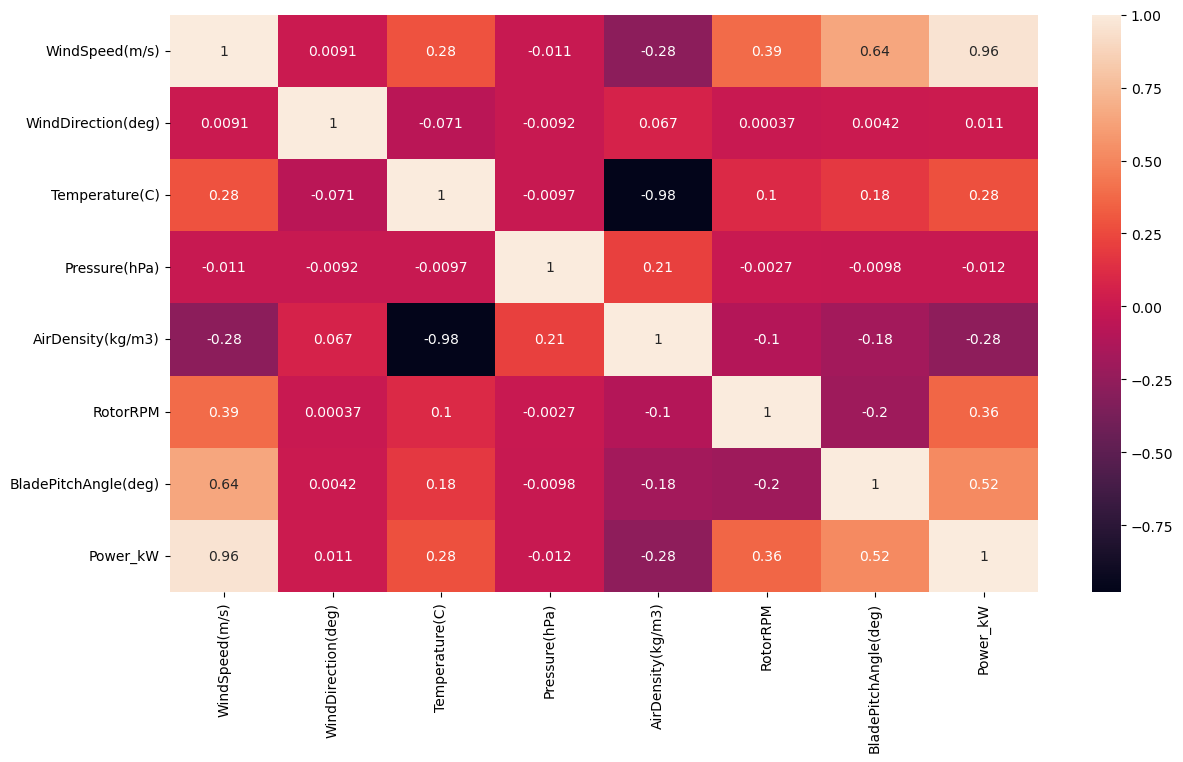

In [35]:
plt.figure(figsize=(14,7.5))
data1=data.drop(['Timestamp'],axis=1)
sns.heatmap(data1.corr(),annot=True)
plt.show()

In [5]:
traget=pd.DataFrame(data.Power_kW)
traget

,Power_kW
0,374.38
1,2134.72
2,160.59
3,250.86
4,2500.00
...,...
13099,364.78
13100,1766.24
13101,648.79
13102,23.62


In [6]:
traget.describe()

,Power_kW
count,13104.000000
mean,1276.892514
std,842.128756
min,0.000000
25%,524.250000
50%,1149.440000
75%,2102.102500
max,2500.000000


In [7]:
features=data.drop(['Timestamp','Power_kW'],axis=1)
features

,WindSpeed(m/s),WindDirection(deg),Temperature(C),Pressure(hPa),AirDensity(kg/m3),RotorRPM,BladePitchAngle(deg)
0,7.78,268.45,19.47,1011.92,1.2047,13.08,2.11
1,11.54,269.18,21.23,1011.70,1.1973,17.79,2.50
2,6.60,264.37,21.90,1012.91,1.1960,10.29,1.78
3,7.18,268.45,21.79,1012.61,1.1961,11.60,2.02
4,12.79,273.51,22.89,1011.92,1.1908,11.30,4.23
...,...,...,...,...,...,...,...
13099,7.74,133.77,26.19,1014.56,1.1807,13.87,2.07
13100,11.02,125.55,24.64,1013.87,1.1861,16.46,2.38
13101,8.74,123.21,27.86,1011.80,1.1710,14.33,2.12
13102,4.90,113.22,28.39,1016.20,1.1740,7.39,2.05


In [8]:
features.describe()

,WindSpeed(m/s),WindDirection(deg),Temperature(C),Pressure(hPa),AirDensity(kg/m3),RotorRPM,BladePitchAngle(deg)
count,13104.000000,13104.000000,13104.000000,13104.000000,13104.000000,13104.000000,13104.000000
mean,9.925314,158.852750,26.705976,1013.228576,1.177272,14.099048,2.927757
std,2.293121,115.120443,2.868338,2.011808,0.011528,2.861209,1.866355
min,1.930000,0.010000,17.990000,1005.890000,1.143500,0.000000,0.000000
25%,8.350000,51.820000,24.660000,1011.870000,1.168700,11.990000,2.190000
50%,9.950000,132.395000,26.690000,1013.230000,1.177200,13.920000,2.360000
75%,11.490000,268.192500,28.830000,1014.580000,1.185500,16.360000,2.580000
max,18.440000,359.910000,35.170000,1021.130000,1.213500,21.780000,20.830000


In [9]:
scale=StandardScaler()

In [10]:
features['Temperature(C)']

0        19.47
1        21.23
2        21.90
3        21.79
4        22.89
         ...  
13099    26.19
13100    24.64
13101    27.86
13102    28.39
13103    26.67
Name: Temperature(C), Length: 13104, dtype: float64

In [11]:
features['WindSpeed(m/s)']=scale.fit_transform(features[['WindSpeed(m/s)']])
features['WindDirection(deg)']=scale.fit_transform(features[['WindDirection(deg)']])
features['Temperature(C)']=scale.fit_transform(features[['Temperature(C)']])
features['Pressure(hPa)']=scale.fit_transform(features[['Pressure(hPa)']])
features['AirDensity(kg/m3)']=scale.fit_transform(features[['AirDensity(kg/m3)']])
features['RotorRPM']=scale.fit_transform(features[['RotorRPM']])
features['BladePitchAngle(deg)']=scale.fit_transform(features[['BladePitchAngle(deg)']])
features

,WindSpeed(m/s),WindDirection(deg),Temperature(C),Pressure(hPa),AirDensity(kg/m3),RotorRPM,BladePitchAngle(deg)
0,-0.935579,0.952059,-2.522803,-0.650473,2.379211,-0.356173,-0.438174
1,0.704171,0.958400,-1.909184,-0.759831,1.737297,1.290047,-0.229203
2,-1.450181,0.916616,-1.675590,-0.158359,1.624528,-1.331323,-0.614996
3,-1.197241,0.952059,-1.713941,-0.307484,1.633202,-0.873457,-0.486398
4,1.249300,0.996014,-1.330429,-0.650473,1.173453,-0.978312,0.697773
...,...,...,...,...,...,...,...
13099,-0.953023,-0.217891,-0.179894,0.661830,0.297327,-0.080056,-0.459607
13100,0.477397,-0.289297,-0.720297,0.318842,0.765751,0.825190,-0.293502
13101,-0.516920,-0.309624,0.402347,-0.710123,-0.544101,0.080722,-0.432816
13102,-2.191557,-0.396406,0.587130,1.477048,-0.283865,-2.344919,-0.470324


In [26]:
features.describe()

,WindSpeed(m/s),WindDirection(deg),Temperature(C),Pressure(hPa),AirDensity(kg/m3),RotorRPM,BladePitchAngle(deg)
count,1.310400e+04,1.310400e+04,1.310400e+04,1.310400e+04,1.310400e+04,1.310400e+04,1.310400e+04
mean,7.482822e-16,3.470294e-17,1.041088e-16,2.580381e-14,-1.249306e-14,6.224840e-16,-1.615856e-16
std,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00
min,-3.486785e+00,-1.379849e+00,-3.038801e+00,-3.647891e+00,-2.929592e+00,-4.927841e+00,-1.568763e+00
25%,-6.869999e-01,-9.297813e-01,-7.133238e-01,-6.753268e-01,-7.436146e-01,-7.371457e-01,-3.953082e-01
50%,1.076581e-02,-2.298355e-01,-5.570001e-03,7.078444e-04,-6.280815e-03,-6.257999e-02,-3.042181e-01
75%,6.823653e-01,9.498219e-01,7.405350e-01,6.717717e-01,7.137039e-01,7.902388e-01,-1.863367e-01
max,3.713285e+00,1.746561e+00,2.950958e+00,3.927674e+00,3.142568e+00,2.684615e+00,9.592457e+00


In [12]:
traget['Power_kW']=scale.fit_transform(traget[['Power_kW']])
traget                                       

,Power_kW
0,-1.071745
1,1.018681
2,-1.325623
3,-1.218426
4,1.452455
...,...
13099,-1.083145
13100,0.581106
13101,-0.745879
13102,-1.488276


In [28]:
traget.describe()

,Power_kW
count,1.310400e+04
mean,-6.940588e-17
std,1.000038e+00
min,-1.516325e+00
25%,-8.937722e-01
50%,-1.513514e-01
75%,9.799469e-01
max,1.452455e+00


In [52]:
import warnings

In [42]:
feeature_train,feature_test,traget_train,traget_test=train_test_split(features,traget,test_size=0.2,random_state=32)

In [44]:
lr=LinearRegression()
lr.fit(feeature_train,traget_train)
lr.score(feature_test,traget_test)

0.947534774057656

In [46]:
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(feeature_train,traget_train)
knn.score(feature_test,traget_test)

0.9819230325241963

In [48]:
dt=DecisionTreeRegressor()
dt.fit(feeature_train,traget_train)
dt.score(feature_test,traget_test)

0.999995670718931

In [60]:
warnings.filterwarnings("ignore")
rf=RandomForestRegressor(n_estimators=30)
warnings.filterwarnings("ignore")
rf.fit(feeature_train,traget_train)
warnings.filterwarnings("ignore")
rf.score(feature_test,traget_test)

0.9999972071022875

In [110]:
traget

,Power_kW
0,-1.071745
1,1.018681
2,-1.325623
3,-1.218426
4,1.452455
...,...
13099,-1.083145
13100,0.581106
13101,-0.745879
13102,-1.488276


In [134]:
model=LinearRegression()
model.fit(features,traget)
model.score(features,traget)
ytrp=np.array(model.predict(feeature_train)).flatten()
ytep=np.array(model.predict(feature_test)).flatten()
ytrain=np.array(traget_train.Power_kW)
ytest=np.array(traget_test.Power_kW)

In [136]:
ytep

array([-0.55620244,  0.28002137, -0.93810759, ..., -0.90567833,
        0.71872208,  0.05314215])

In [138]:
def plot_model_predictions(ytrain, ytrp, ytest, ytep, model_name="Model"):
    import seaborn as sns
    fig, axes = plt.subplots(11, 1, figsize=(16, 55))  # 11 vertical subplots

    sns.lineplot(x=range(2000), y=ytrain[:2000], color='blue', alpha=0.5, ax=axes[0])
    sns.lineplot(x=range(2000), y=ytrp[:2000], color='green', alpha=0.5, ax=axes[0])
    axes[0].set_title(f"{model_name} - Full Train vs Predicted")
    
    sns.lineplot(x=range(200), y=ytrain[:200], color='blue', ax=axes[1])
    sns.lineplot(x=range(200), y=ytrp[:200], color='green', alpha=0.7, ax=axes[1])
    axes[1].set_title(f"{model_name} - First 200 Train vs Predicted")
    
    sns.lineplot(x=range(200), y=ytrain[:200], color='blue', ax=axes[2])
    axes[2].set_title(f"{model_name} - First 200 Train Only")
    
    sns.lineplot(x=range(200), y=ytrp[:200], color='green', ax=axes[3])
    axes[3].set_title(f"{model_name} - First 200 Predicted Train Only")
    
    sns.lineplot(x=ytrain[:20000], y=ytrp[:20000], color='orange', ax=axes[4])
    axes[4].set_title(f"{model_name} - Train vs Predicted Scatter")
    
    sns.lineplot(x=ytrain[:200], y=ytrp[:200], color='orange', ax=axes[5])
    axes[5].set_title(f"{model_name} - First 200 Train vs Predicted Scatter")
    
    sns.lineplot(x=range(200), y=ytest[:200], color='blue', ax=axes[6])
    sns.lineplot(x=range(200), y=ytep[:200], color='green', alpha=0.7, ax=axes[6])
    axes[6].set_title(f"{model_name} - First 200 Test vs Predicted")
    
    sns.lineplot(x=range(200), y=ytest[:200], color='blue', ax=axes[7])
    axes[7].set_title(f"{model_name} - First 200 Test Only")
    
    sns.lineplot(x=range(200), y=ytep[:200], color='green', ax=axes[8])
    axes[8].set_title(f"{model_name} - First 200 Predicted Test Only")
    
    sns.lineplot(x=ytest, y=ytep, color='orange', ax=axes[9])
    axes[9].set_title(f"{model_name} - Test vs Predicted Scatter")

    sns.lineplot(x=ytest[:200], y=ytep[:200], color='orange', ax=axes[10])
    axes[10].set_title(f"{model_name} - First 200 Test vs Predicted Scatter")
    
    plt.tight_layout()
    plt.show()

In [140]:
import joblib
joblib.dump(model,"wind_power_prediction.pkl")

['wind_power_prediction.pkl']

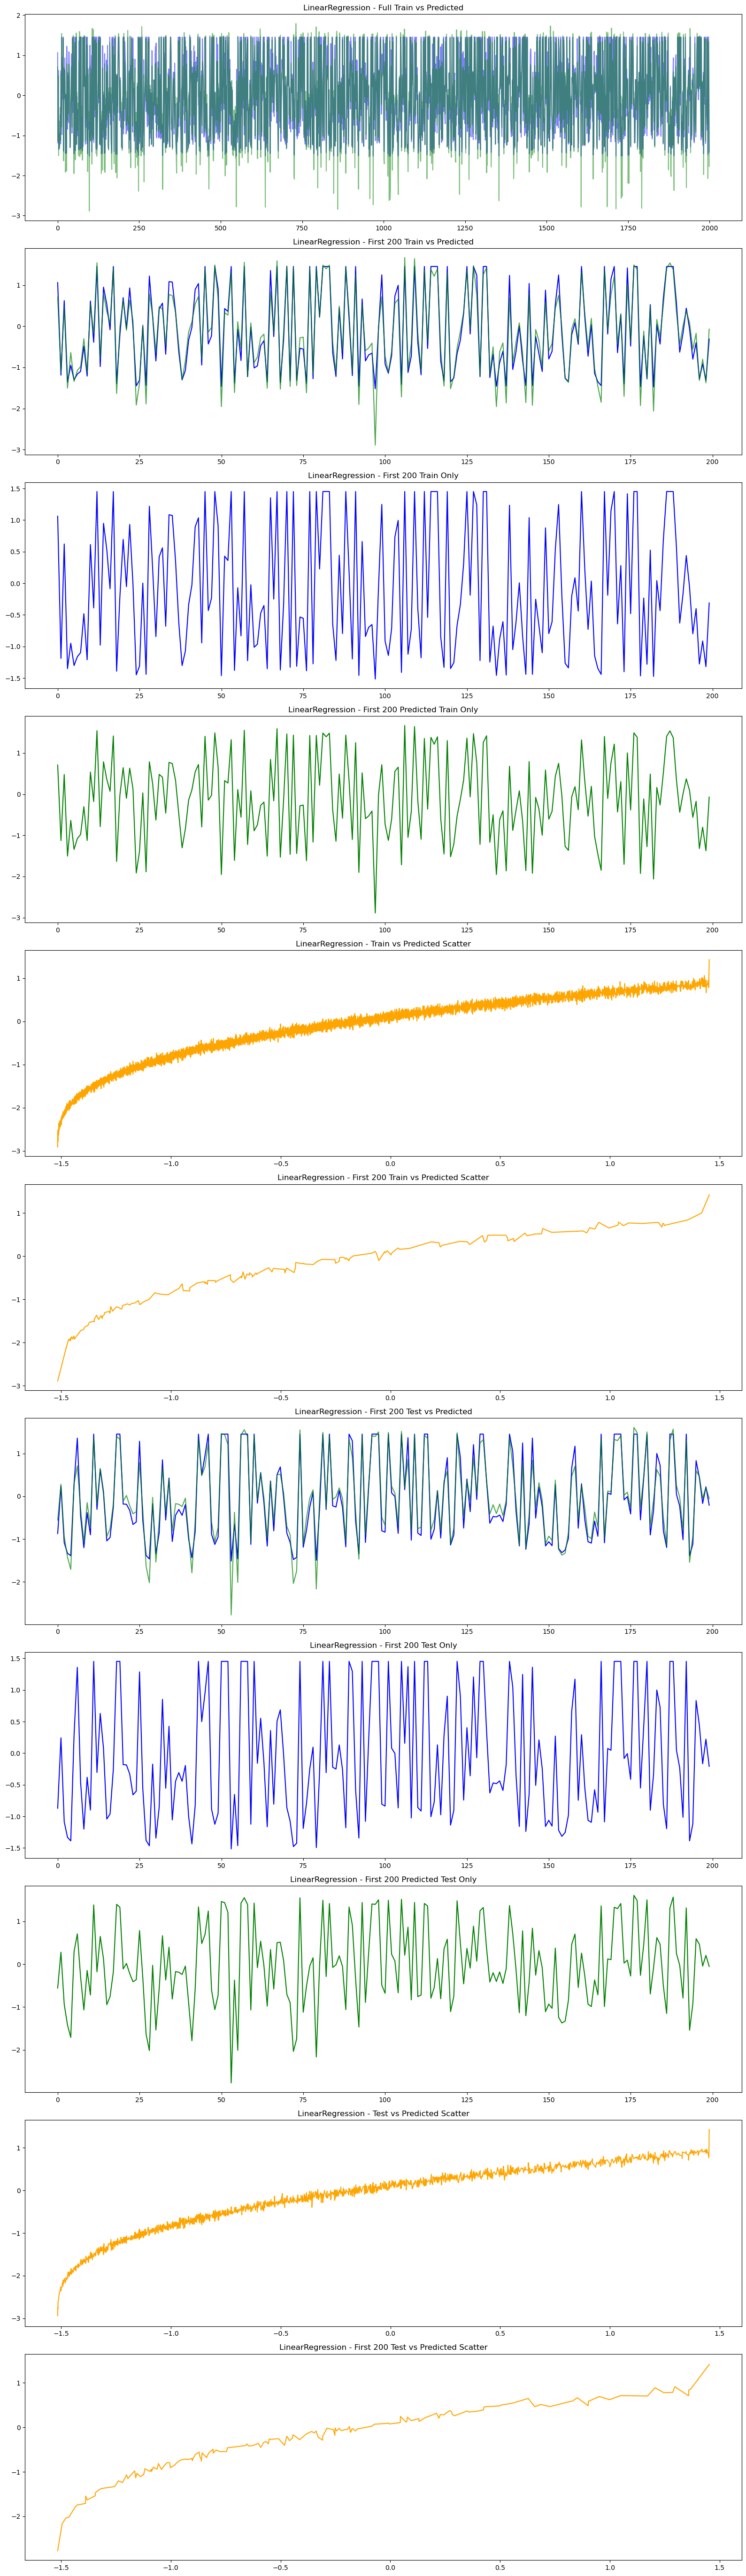

In [142]:
plot_model_predictions(ytrain, ytrp, ytest, ytep, model_name="LinearRegression")

In [7]:
def pred(model="wind_power_prediction.pkl"):

    import sklearn
    import joblib
    mod=joblib.load("wind_power_prediction.pkl")
    
    WindSpeed=float(input("WindSpeed(m/s): "))
    WindDirection=float(input("WindDirection(deg): "))
    Temperature=float(input("Temperature(C): "))
    Pressure=float(input("Pressure(hPa): "))
    AirDensity=float(input("AirDensity(kg/m3): "))
    RotorRPM=float(input("RotorRPM: "))
    BladePitchAngle=float(input("BladePitchAngle(deg): "))
    x=[[WindSpeed,WindDirection,Temperature,Pressure,AirDensity,RotorRPM,BladePitchAngle]]

    ans=mod.predict(x)

    return ans.item()

In [9]:
pred()

WindSpeed(m/s):  50
WindDirection(deg):  50
Temperature(C):  50
Pressure(hPa):  550
AirDensity(kg/m3):  50
RotorRPM:  50
BladePitchAngle(deg):  50


C:\Users\shankar\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


33.63254799236284

NameError: name 'model_code' is not defined